# Gaia GSP-Phot Quality Flag Analysis

This notebook analyzes the Gaia GSP-Phot temperature quality flags for our eclipsing binary catalog.

**Goals:**
1. Understand the distribution of quality flags (flag 0 vs flag 1)
2. Check for bias between flag 0 and flag 1 sources in:
   - Temperature distribution
   - Magnitude distribution  
   - Color distributions
3. Decide if we should use only flag 1 sources for ML training

**Date:** 2025-10-13


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.notebook_utils import save_figure, MISSING_VALUE
from src.config import get_config

# Plotting configuration
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

config = get_config()
print("Setup complete!")


Setup complete!


In [2]:
# Load data with quality flags
data_file = config.project_root / 'data' / 'processed' / 'ml_training_data_with_gaia_with_flags.parquet'
df = pd.read_parquet(data_file)

print(f"Loaded {len(df):,} eclipsing binaries")
print(f"\nColumns: {list(df.columns)}")
print(f"\nQuality flag distribution:")
flag_counts = df['teff_gspphot_flag'].value_counts().sort_index()
print(flag_counts)
print(f"\nFlag 0 (lower quality): {flag_counts[0]:,} ({flag_counts[0]/len(df)*100:.1f}%)")
print(f"Flag 1 (higher quality): {flag_counts[1]:,} ({flag_counts[1]/len(df)*100:.1f}%)")


Loaded 705,998 eclipsing binaries

Columns: ['original_ext_source_id', 'g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'gPSFMag', 'teff_gspphot', 'bp_rp', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'source_id', 'teff_gspphot_flag']

Quality flag distribution:
teff_gspphot_flag
0    287146
1    418852
Name: count, dtype: int64

Flag 0 (lower quality): 287,146 (40.7%)
Flag 1 (higher quality): 418,852 (59.3%)


✓ Saved figure: reports/figures/quality_analysis/quality_flag_distribution.png


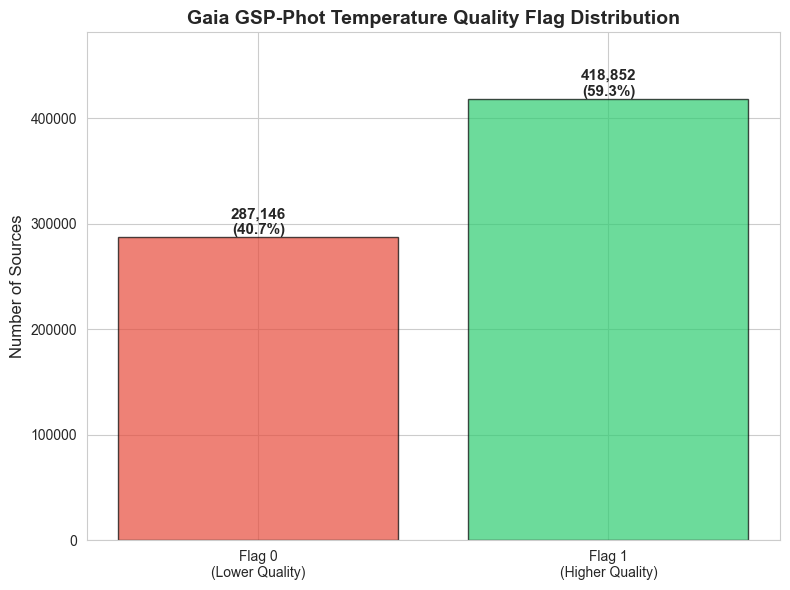

Total sources: 705,998
High-quality sources (flag 1): 418,852 (59.3%)


In [3]:
# Visualize quality flag distribution
fig, ax = plt.subplots(figsize=(8, 6))

flag_counts = df['teff_gspphot_flag'].value_counts().sort_index()
colors = ['#e74c3c', '#2ecc71']  # Red for flag 0, green for flag 1
bars = ax.bar(['Flag 0\n(Lower Quality)', 'Flag 1\n(Higher Quality)'], 
               flag_counts.values, color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Sources', fontsize=12)
ax.set_title('Gaia GSP-Phot Temperature Quality Flag Distribution', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(flag_counts.values) * 1.15)
plt.tight_layout()
save_figure(fig, 'quality_flag_distribution.png', subdir='quality_analysis')
plt.show()

print(f"Total sources: {len(df):,}")
print(f"High-quality sources (flag 1): {flag_counts[1]:,} ({flag_counts[1]/len(df)*100:.1f}%)")


✓ Saved figure: reports/figures/quality_analysis/temperature_comparison_by_flag.png


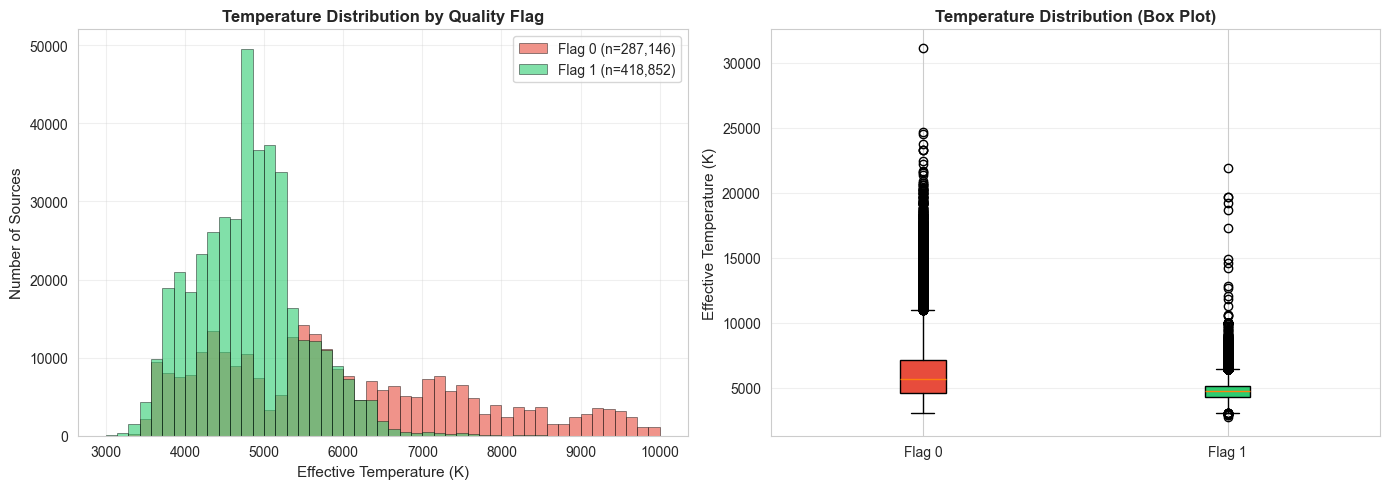

Temperature statistics:

Flag 0 (lower quality):
  Mean: 6062.2 K
  Median: 5691.3 K
  Std: 1833.7 K

Flag 1 (higher quality):
  Mean: 4806.4 K
  Median: 4787.9 K
  Std: 682.3 K


In [5]:
# Compare temperature distributions by quality flag
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate data by flag
df_flag0 = df[df['teff_gspphot_flag'] == 0]
df_flag1 = df[df['teff_gspphot_flag'] == 1]

# Histogram comparison
ax = axes[0]
bins = np.linspace(3000, 10000, 50)
ax.hist(df_flag0['teff_gspphot'], bins=bins, alpha=0.6, color='#e74c3c', 
        label=f'Flag 0 (n={len(df_flag0):,})', edgecolor='black', linewidth=0.5)
ax.hist(df_flag1['teff_gspphot'], bins=bins, alpha=0.6, color='#2ecc71', 
        label=f'Flag 1 (n={len(df_flag1):,})', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Effective Temperature (K)', fontsize=11)
ax.set_ylabel('Number of Sources', fontsize=11)
ax.set_title('Temperature Distribution by Quality Flag', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Box plot comparison
ax = axes[1]
data_to_plot = [df_flag0['teff_gspphot'], df_flag1['teff_gspphot']]
bp = ax.boxplot(data_to_plot, tick_labels=['Flag 0', 'Flag 1'], patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')
ax.set_ylabel('Effective Temperature (K)', fontsize=11)
ax.set_title('Temperature Distribution (Box Plot)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
save_figure(fig, 'temperature_comparison_by_flag.png', subdir='quality_analysis')
plt.show()

# Statistics
print("Temperature statistics:")
print(f"\nFlag 0 (lower quality):")
print(f"  Mean: {df_flag0['teff_gspphot'].mean():.1f} K")
print(f"  Median: {df_flag0['teff_gspphot'].median():.1f} K")
print(f"  Std: {df_flag0['teff_gspphot'].std():.1f} K")
print(f"\nFlag 1 (higher quality):")
print(f"  Mean: {df_flag1['teff_gspphot'].mean():.1f} K")
print(f"  Median: {df_flag1['teff_gspphot'].median():.1f} K")
print(f"  Std: {df_flag1['teff_gspphot'].std():.1f} K")


✓ Saved figure: reports/figures/quality_analysis/magnitude_comparison_by_flag.png


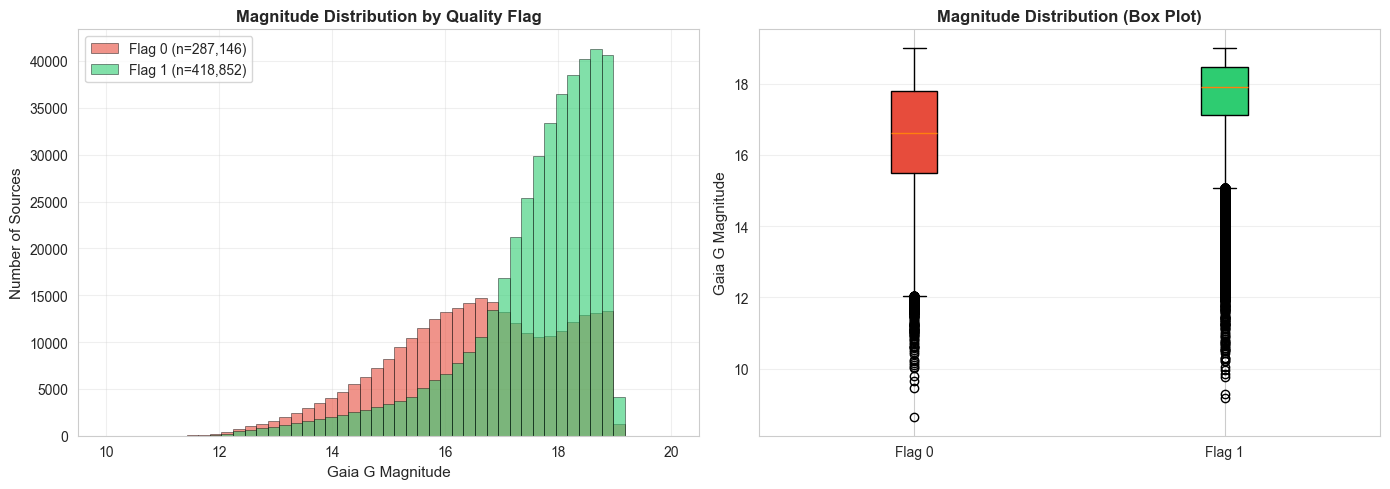

Gaia G magnitude statistics:

Flag 0 (lower quality):
  Mean: 16.54
  Median: 16.62
  Std: 1.54

Flag 1 (higher quality):
  Mean: 17.58
  Median: 17.91
  Std: 1.25


In [6]:
# Compare magnitude distributions by quality flag
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax = axes[0]
bins = np.linspace(10, 20, 50)
ax.hist(df_flag0['phot_g_mean_mag'], bins=bins, alpha=0.6, color='#e74c3c', 
        label=f'Flag 0 (n={len(df_flag0):,})', edgecolor='black', linewidth=0.5)
ax.hist(df_flag1['phot_g_mean_mag'], bins=bins, alpha=0.6, color='#2ecc71', 
        label=f'Flag 1 (n={len(df_flag1):,})', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Gaia G Magnitude', fontsize=11)
ax.set_ylabel('Number of Sources', fontsize=11)
ax.set_title('Magnitude Distribution by Quality Flag', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Box plot comparison
ax = axes[1]
data_to_plot = [df_flag0['phot_g_mean_mag'], df_flag1['phot_g_mean_mag']]
bp = ax.boxplot(data_to_plot, tick_labels=['Flag 0', 'Flag 1'], patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')
ax.set_ylabel('Gaia G Magnitude', fontsize=11)
ax.set_title('Magnitude Distribution (Box Plot)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
save_figure(fig, 'magnitude_comparison_by_flag.png', subdir='quality_analysis')
plt.show()

# Statistics
print("Gaia G magnitude statistics:")
print(f"\nFlag 0 (lower quality):")
print(f"  Mean: {df_flag0['phot_g_mean_mag'].mean():.2f}")
print(f"  Median: {df_flag0['phot_g_mean_mag'].median():.2f}")
print(f"  Std: {df_flag0['phot_g_mean_mag'].std():.2f}")
print(f"\nFlag 1 (higher quality):")
print(f"  Mean: {df_flag1['phot_g_mean_mag'].mean():.2f}")
print(f"  Median: {df_flag1['phot_g_mean_mag'].median():.2f}")
print(f"  Std: {df_flag1['phot_g_mean_mag'].std():.2f}")


✓ Saved figure: reports/figures/quality_analysis/bp_rp_color_comparison_by_flag.png


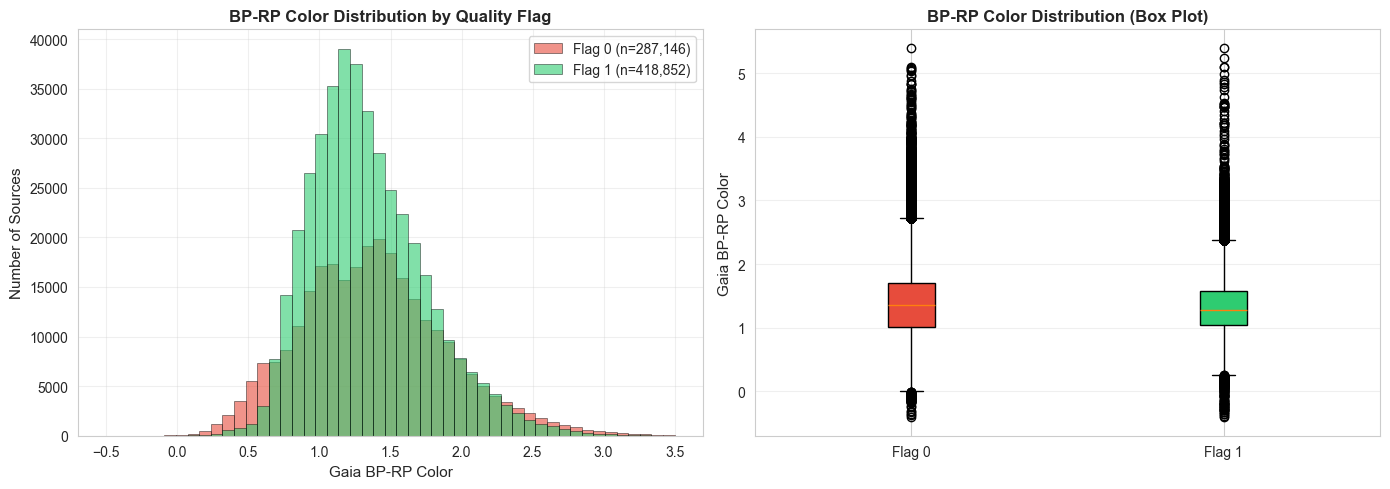

Gaia BP-RP color statistics:

Flag 0 (lower quality):
  Mean: 1.384
  Median: 1.357
  Std: 0.526

Flag 1 (higher quality):
  Mean: 1.338
  Median: 1.278
  Std: 0.411


In [7]:
# Compare Gaia BP-RP color distributions by quality flag
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax = axes[0]
bins = np.linspace(-0.5, 3.5, 50)
ax.hist(df_flag0['bp_rp'], bins=bins, alpha=0.6, color='#e74c3c', 
        label=f'Flag 0 (n={len(df_flag0):,})', edgecolor='black', linewidth=0.5)
ax.hist(df_flag1['bp_rp'], bins=bins, alpha=0.6, color='#2ecc71', 
        label=f'Flag 1 (n={len(df_flag1):,})', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Gaia BP-RP Color', fontsize=11)
ax.set_ylabel('Number of Sources', fontsize=11)
ax.set_title('BP-RP Color Distribution by Quality Flag', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Box plot comparison
ax = axes[1]
data_to_plot = [df_flag0['bp_rp'], df_flag1['bp_rp']]
bp = ax.boxplot(data_to_plot, tick_labels=['Flag 0', 'Flag 1'], patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')
ax.set_ylabel('Gaia BP-RP Color', fontsize=11)
ax.set_title('BP-RP Color Distribution (Box Plot)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
save_figure(fig, 'bp_rp_color_comparison_by_flag.png', subdir='quality_analysis')
plt.show()

# Statistics
print("Gaia BP-RP color statistics:")
print(f"\nFlag 0 (lower quality):")
print(f"  Mean: {df_flag0['bp_rp'].mean():.3f}")
print(f"  Median: {df_flag0['bp_rp'].median():.3f}")
print(f"  Std: {df_flag0['bp_rp'].std():.3f}")
print(f"\nFlag 1 (higher quality):")
print(f"  Mean: {df_flag1['bp_rp'].mean():.3f}")
print(f"  Median: {df_flag1['bp_rp'].median():.3f}")
print(f"  Std: {df_flag1['bp_rp'].std():.3f}")


✓ Saved figure: reports/figures/quality_analysis/panstarrs_colors_comparison_by_flag.png


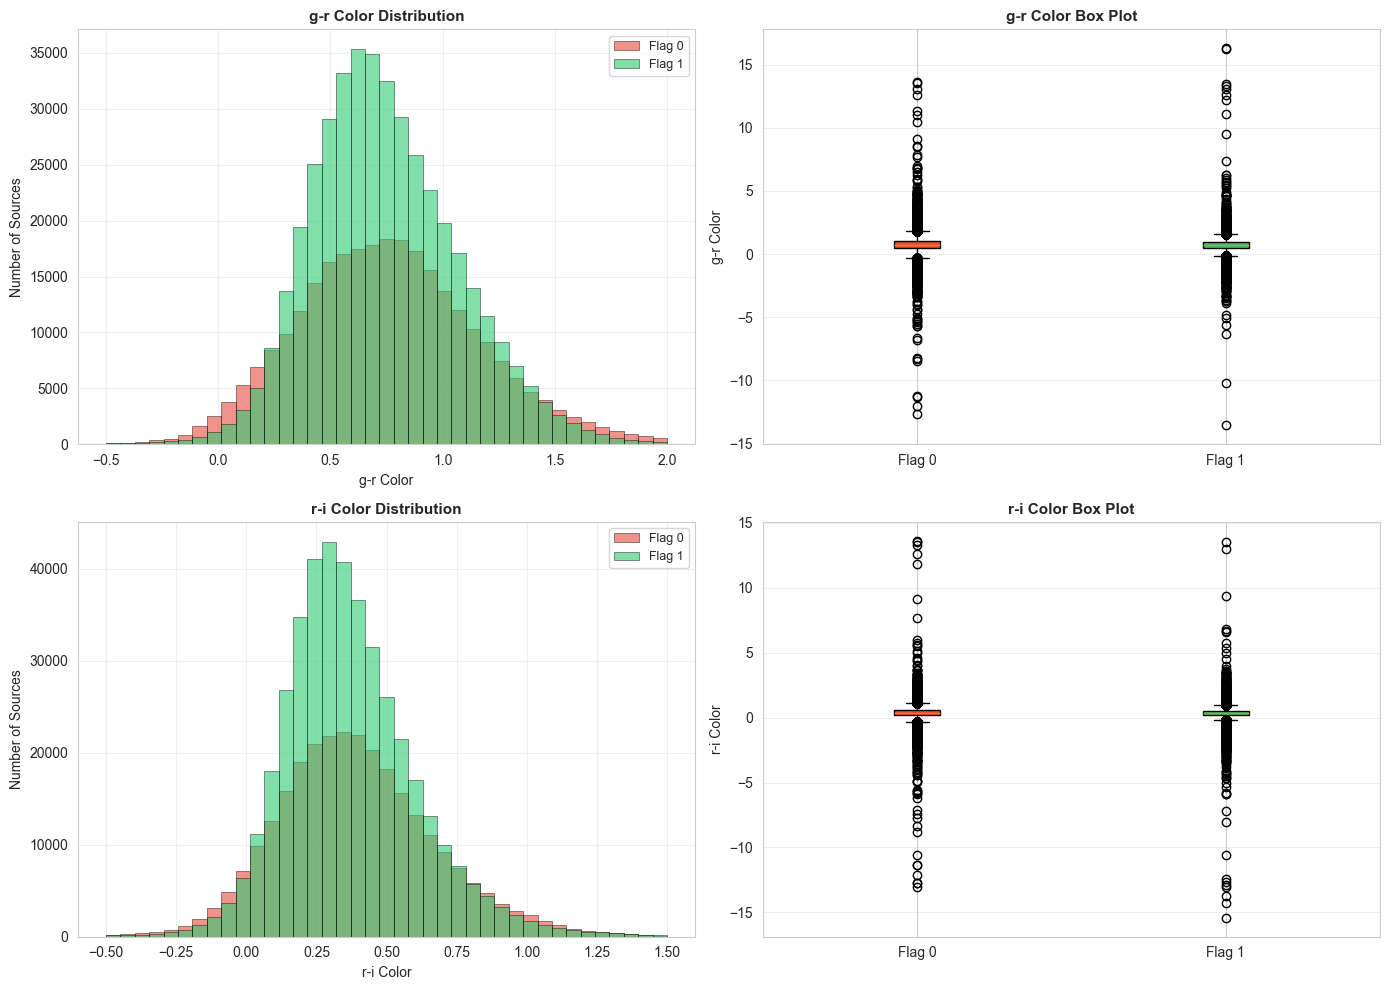

Pan-STARRS color statistics:

g-r color:
  Flag 0: mean=0.762, median=0.744
  Flag 1: mean=0.743, median=0.712

r-i color:
  Flag 0: mean=0.389, median=0.371
  Flag 1: mean=0.370, median=0.343


In [8]:
# Compare Pan-STARRS color distributions by quality flag
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# g-r color histogram
ax = axes[0, 0]
bins = np.linspace(-0.5, 2, 40)
ax.hist(df_flag0['g_r_color'], bins=bins, alpha=0.6, color='#e74c3c', 
        label=f'Flag 0', edgecolor='black', linewidth=0.5)
ax.hist(df_flag1['g_r_color'], bins=bins, alpha=0.6, color='#2ecc71', 
        label=f'Flag 1', edgecolor='black', linewidth=0.5)
ax.set_xlabel('g-r Color', fontsize=10)
ax.set_ylabel('Number of Sources', fontsize=10)
ax.set_title('g-r Color Distribution', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# g-r color box plot
ax = axes[0, 1]
bp = ax.boxplot([df_flag0['g_r_color'], df_flag1['g_r_color']], 
                tick_labels=['Flag 0', 'Flag 1'], patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')
ax.set_ylabel('g-r Color', fontsize=10)
ax.set_title('g-r Color Box Plot', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# r-i color histogram
ax = axes[1, 0]
bins = np.linspace(-0.5, 1.5, 40)
ax.hist(df_flag0['r_i_color'], bins=bins, alpha=0.6, color='#e74c3c', 
        label=f'Flag 0', edgecolor='black', linewidth=0.5)
ax.hist(df_flag1['r_i_color'], bins=bins, alpha=0.6, color='#2ecc71', 
        label=f'Flag 1', edgecolor='black', linewidth=0.5)
ax.set_xlabel('r-i Color', fontsize=10)
ax.set_ylabel('Number of Sources', fontsize=10)
ax.set_title('r-i Color Distribution', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# r-i color box plot
ax = axes[1, 1]
bp = ax.boxplot([df_flag0['r_i_color'], df_flag1['r_i_color']], 
                tick_labels=['Flag 0', 'Flag 1'], patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')
ax.set_ylabel('r-i Color', fontsize=10)
ax.set_title('r-i Color Box Plot', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
save_figure(fig, 'panstarrs_colors_comparison_by_flag.png', subdir='quality_analysis')
plt.show()

# Statistics
print("Pan-STARRS color statistics:")
print(f"\ng-r color:")
print(f"  Flag 0: mean={df_flag0['g_r_color'].mean():.3f}, median={df_flag0['g_r_color'].median():.3f}")
print(f"  Flag 1: mean={df_flag1['g_r_color'].mean():.3f}, median={df_flag1['g_r_color'].median():.3f}")
print(f"\nr-i color:")
print(f"  Flag 0: mean={df_flag0['r_i_color'].mean():.3f}, median={df_flag0['r_i_color'].median():.3f}")
print(f"  Flag 1: mean={df_flag1['r_i_color'].mean():.3f}, median={df_flag1['r_i_color'].median():.3f}")


✓ Saved figure: reports/figures/quality_analysis/hr_diagram_hexbin_by_flag.png


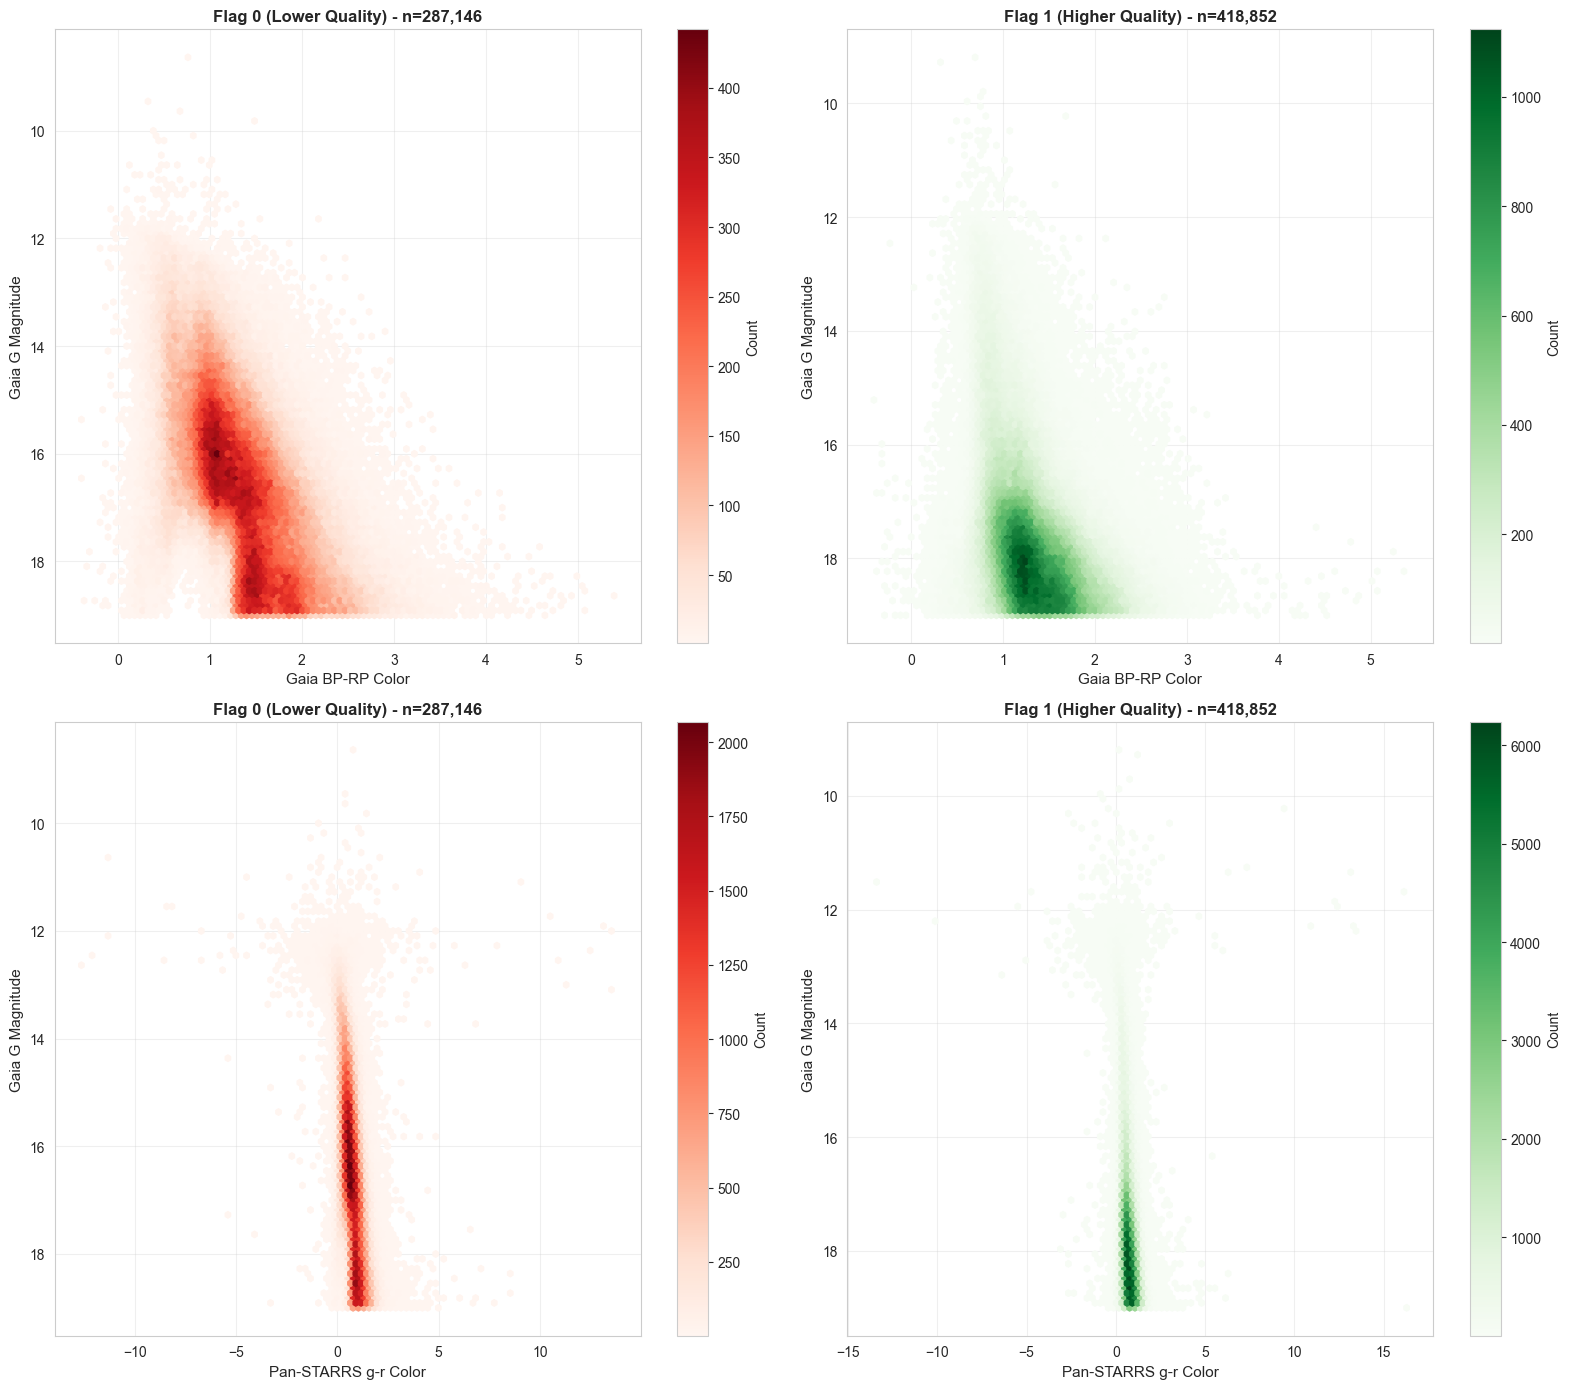

In [11]:
# H-R Diagram using hexbin density plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Flag 0 - BP-RP
ax = axes[0, 0]
hb = ax.hexbin(df_flag0['bp_rp'], df_flag0['phot_g_mean_mag'], gridsize=100, cmap='Reds', mincnt=1)
ax.set_xlabel('Gaia BP-RP Color', fontsize=11)
ax.set_ylabel('Gaia G Magnitude', fontsize=11)
ax.set_title(f'Flag 0 (Lower Quality) - n={len(df_flag0):,}', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.colorbar(hb, ax=ax, label='Count')
ax.grid(alpha=0.3)

# Flag 1 - BP-RP
ax = axes[0, 1]
hb = ax.hexbin(df_flag1['bp_rp'], df_flag1['phot_g_mean_mag'], gridsize=100, cmap='Greens', mincnt=1)
ax.set_xlabel('Gaia BP-RP Color', fontsize=11)
ax.set_ylabel('Gaia G Magnitude', fontsize=11)
ax.set_title(f'Flag 1 (Higher Quality) - n={len(df_flag1):,}', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.colorbar(hb, ax=ax, label='Count')
ax.grid(alpha=0.3)

# Flag 0 - g-r
ax = axes[1, 0]
hb = ax.hexbin(df_flag0['g_r_color'], df_flag0['phot_g_mean_mag'], gridsize=100, cmap='Reds', mincnt=1)
ax.set_xlabel('Pan-STARRS g-r Color', fontsize=11)
ax.set_ylabel('Gaia G Magnitude', fontsize=11)
ax.set_title(f'Flag 0 (Lower Quality) - n={len(df_flag0):,}', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.colorbar(hb, ax=ax, label='Count')
ax.grid(alpha=0.3)

# Flag 1 - g-r
ax = axes[1, 1]
hb = ax.hexbin(df_flag1['g_r_color'], df_flag1['phot_g_mean_mag'], gridsize=100, cmap='Greens', mincnt=1)
ax.set_xlabel('Pan-STARRS g-r Color', fontsize=11)
ax.set_ylabel('Gaia G Magnitude', fontsize=11)
ax.set_title(f'Flag 1 (Higher Quality) - n={len(df_flag1):,}', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.colorbar(hb, ax=ax, label='Count')
ax.grid(alpha=0.3)

plt.tight_layout()
save_figure(fig, 'hr_diagram_hexbin_by_flag.png', subdir='quality_analysis', dpi=150)
plt.show()
